# LLM Evaluation
Sends anonimized or artificial medical records to external LLM apis for structured feedback. Due to personal data restriction, personal (real) notes can not be sent to openai, claude etc. Instead, anonymized notes or use local LLMs. 
Writes verdicts to `outputs/feedback/`. 

You will need to have an OpenAI API key to run this notebook. Or You can connect with a bigger local LLM. 

In [ ]:
import json
import os
import openai
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')

if not OPENAI_API_KEY:
    raise EnvironmentError('Set the OPENAI_API_KEY environment variable before running this notebook.')

client = openai.OpenAI(api_key=OPENAI_API_KEY)
Path('../outputs/feedback').mkdir(exist_ok=True)

def ask(system: str, user: str) -> dict:
    r = client.chat.completions.create(
        model='gpt-3.5-turbo',
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user', 'content': user}
        ],
        max_tokens=800,
        temperature=0.0,
    )

    choice = r.choices[0]
    message = getattr(choice, 'message', None)
    if isinstance(message, dict):
        text = message.get('content', '')
    else:
        text = getattr(message, 'content', '')

    return json.loads(text.strip())

In [14]:
DEID_SYS = """
You are a clinical privacy expert. Evaluate de-identification quality.
Return ONLY valid JSON:
{"verdict": "PASS"|"FAIL", "missed_pii": [], "over_redacted": [], "confidence": 0.0-1.0, "note": ""}
"""

NER_SYS = """
You are a clinical NLP expert. Evaluate clinical entity extraction quality.
Return ONLY valid JSON:
{"verdict": "GOOD"|"ACCEPTABLE"|"POOR", "missed": [], "wrong_label": [], "false_positives": [], "confidence": 0.0-1.0, "note": ""}
"""

deid_results, ner_results = [], []

for pf in sorted(Path('../outputs/privacy').glob('*_privacy.json')):
    note_id = pf.stem.replace('_privacy','')
    priv = json.loads(pf.read_text())
    mf = Path('../outputs/medical') / f'{note_id}_medical.json'

    # DeID eval
    try:
        v = ask(DEID_SYS, f"ORIGINAL:\n{priv['original_text']}\n\nREDACTED:\n{priv['redacted_text']}\n\nPII:{json.dumps(priv['pii_entities'])}")
        v['note_id'] = note_id
        deid_results.append(v)
        Path(f'../outputs/feedback/{note_id}_deid.json').write_text(json.dumps(v, indent=2))
        print(f'{note_id}: deid={v["verdict"]} ({v["confidence"]})')
    except Exception as e:
        print(f'{note_id}: deid ERROR {e}')

    # NER eval (only if medical record exists)
    if mf.exists():
        med = json.loads(mf.read_text())
        try:
            v = ask(NER_SYS, f"NOTE:\n{med['redacted_text']}\n\nENTITIES:{json.dumps(med['entities'])}")
            v['note_id'] = note_id
            ner_results.append(v)
            Path(f'../outputs/feedback/{note_id}_ner.json').write_text(json.dumps(v, indent=2))
            print(f'{note_id}: ner={v["verdict"]} ({v["confidence"]})')
        except Exception as e:
            print(f'{note_id}: ner ERROR {e}')

note_001_copd: deid ERROR Expecting value: line 1 column 1 (char 0)
note_001_copd: ner=GOOD (1.0)
note_002_ra: deid ERROR Expecting value: line 1 column 1 (char 0)
note_002_ra: ner=ACCEPTABLE (1.0)
note_003_ami: deid=FAIL (0.0)
note_003_ami: ner=ACCEPTABLE (0.0)
note_004_diabetes: deid=FAIL (0.0)
note_005_oncology: deid=FAIL (0.0)
note_006_stroke: deid=FAIL (0.0)
note_007_sepsis: deid=FAIL (0.0)
note_008_depression: deid=PASS (1.0)
note_009_ckd: deid=FAIL (0.0)
note_010_asthma_paeds: deid=PASS (1.0)
note_010_asthma_paeds: ner=GOOD (1.0)
note: deid ERROR Expecting value: line 1 column 1 (char 0)
note: ner=GOOD (1.0)


,note_id,verdict,confidence,note
0,note_003_ami,FAIL,0.0,The de-identification process failed to fully ...
1,note_004_diabetes,FAIL,0.0,The de-identification process failed as it mis...
2,note_005_oncology,FAIL,0.0,The de-identification process failed as it mis...
3,note_006_stroke,FAIL,0.0,The de-identification process failed as it mis...
4,note_007_sepsis,FAIL,0.0,The de-identification process failed to fully ...
5,note_008_depression,PASS,1.0,
6,note_009_ckd,FAIL,0.0,The de-identification process failed as the oc...
7,note_010_asthma_paeds,PASS,1.0,


,note_id,verdict,confidence,note
0,note_001_copd,GOOD,1.0,
1,note_002_ra,ACCEPTABLE,1.0,
2,note_003_ami,ACCEPTABLE,0.0,
3,note_010_asthma_paeds,GOOD,1.0,
4,note,GOOD,1.0,


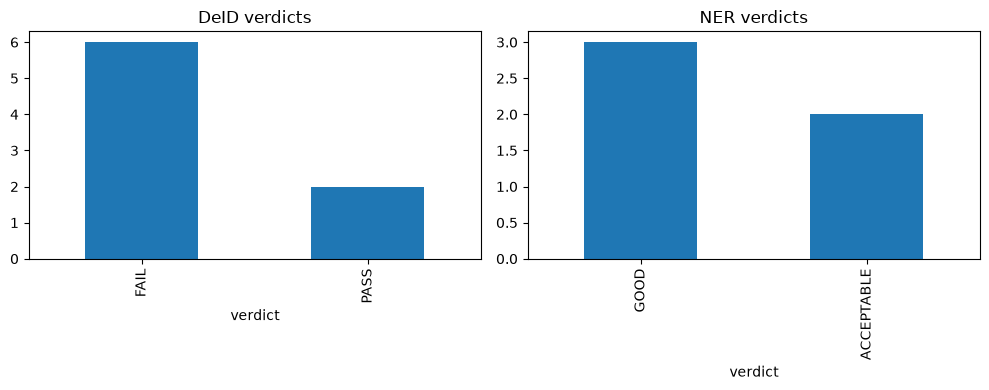

Feedback saved to outputs/feedback/


In [15]:
# Summary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if deid_results:
    df_d = pd.DataFrame(deid_results)
    df_d['verdict'].value_counts().plot.bar(ax=axes[0], title='DeID verdicts')
    display(df_d[['note_id','verdict','confidence','note']])

if ner_results:
    df_n = pd.DataFrame(ner_results)
    df_n['verdict'].value_counts().plot.bar(ax=axes[1], title='NER verdicts')
    display(df_n[['note_id','verdict','confidence','note']])

plt.tight_layout(); plt.show()
print('Feedback saved to outputs/feedback/')

In [ ]:
### TODO : ADD MORE EVALUATION METRICS (e.g., precision, recall, F1) AND VISUALIZATIONS FOR NER AND DEID RESULTS